<a href="https://colab.research.google.com/github/lazybear-0425/EWC_Observation/blob/main/2025-03-25_23_13_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 - Life Lone Learning
 - Elastic Weight Consolidation (EWC)
    - [教學](https://www.kaggle.com/code/hughiephan/elastic-weight-consolidation-on-minst)
    - [Paper](https://arxiv.org/pdf/1612.00796)
    - 公式 $\mathcal{L}(\theta) = \mathcal{L}_B(\theta) + \frac\lambda2\sum^n_{i=1}F_i(\theta_i - \theta^*_{A,i})^2$
        - B是指目前任務，A是指前一個任務
 - [教學2](https://github.com/ContinualAI/colab/blob/master/notebooks/intro_to_continual_learning.ipynb)

In [1]:
import torch
from torch import nn
from torchvision.transforms import Compose, ToTensor, Normalize, RandomRotation, Lambda
import numpy as np
from torchvision.datasets import MNIST as FashionMNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD
from torch.nn.functional import cross_entropy

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
import random

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True  # 確保 CuDNN 使用確定性算法
torch.backends.cudnn.benchmark = False  # 禁止自適應選擇最佳內核，確保結果可重現

In [4]:
batch_size = 256
epochs = 10
task = 2

 - [ToTensor](https://pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html)

In [5]:
def trans_compose(i=0):
    return Compose([
        # lambda x : np.rot90(x, i, axes=[0, 1]).copy(), # 使連續
        # lambda x: np.expand_dims(x, axis=-1),  # 因為ToTensor要PIL or ndarray(H x W x C)，之後轉成Tensor(C x H x W)
        ToTensor(),
        # Lambda(lambda x : x / 255.),
        RandomRotation((90 * i, 90 * i)),
        Normalize(mean=[0.0], std=[1])
    ])

In [6]:
# preprocessing
# train_task_1 = FashionMNIST('data', train=True, transform=trans_compose(0), download=True)
# train_task_2 = FashionMNIST('data', train=True, transform=trans_compose(1), download=True)

test_task_1 = FashionMNIST('data', train=False, transform=trans_compose(0), download=True)
test_task_2 = FashionMNIST('data', train=False, transform=trans_compose(1), download=True)

task_1_loader = DataLoader(test_task_1, batch_size=batch_size, pin_memory=True)
task_2_loader = DataLoader(test_task_2, batch_size=batch_size, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.48MB/s]


In [7]:
class Module(nn.Module):
    def __init__(self):
        super(Module, self).__init__()
        # self.classifier = nn.Sequential(
        #     nn.Conv2d(1, 10, kernel_size=5),
        #     nn.MaxPool2d(2),
        #     nn.ReLU(),
        #     nn.Conv2d(10, 20, kernel_size=5),
        #     nn.Dropout2d(),
        #     nn.MaxPool2d(2),
        #     nn.ReLU(),
        # )
        # self.dense = nn.Sequential(
        #     nn.Linear(320, 50),
        #     nn.ReLU(),
        #     nn.Dropout(),
        #     nn.Linear(50, 10)
        # )
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(10)
        )
    def forward(self, X):
        # return self.dense(self.classifier(X).view(-1, 320))
        return self.net(X)

In [8]:
def evaluate(model, dataloader, num_data, num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")

    test_acc = 0
    test_loss = 0
    with torch.no_grad():
        model.eval()
        for data in dataloader:
            img, label = data
            img, label = img.to(device), label.to(device).long()
            output = model(img)
            test_loss += cross_entropy(output, label)
            test_acc += (output.argmax(1) == label).sum()
    print('\033[33m' +
          f'Task {num_task} Acc: {test_acc / num_data: .4f}, Loss: {test_loss / num_data: .4f}' +
          '\033[0m')

In [9]:
def training_Setting(model):
    optimizer = Adam(model.parameters())
    loss = CrossEntropyLoss()
    return optimizer, loss

 - Fisher Matrix
     - 儲存權重對模型重要性
     - 計算方法
         - [LINK](https://github.com/db434/EWC)
             - 這個版本是**取樣** $\rightarrow$ 計算梯度
         - 這邊的範例程式碼是直接**整個資料**來計算梯度
         - 公式
             - $F_j = \frac1m \sum^m_{i=1}(\frac{\partial \log (P(x_i|\theta_j))}{\partial \theta_j})^2$

In [10]:
# EWC
optim_para = {}
fisher_matrix = {}
ewc_lambda = 10

def record_parameter(model, train_data, optimizer, num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")
    global optim_para, fisher_matrix, ewc_lambda
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
    model.train()
    optimizer.zero_grad()

    fisher_matrix[num_task] = {}
    optim_para[num_task] = {}

    # Initialize Fisher Matrix
    for name, param in model.named_parameters():
        fisher_matrix[num_task][name] = torch.zeros_like(param.data)

    idx = 0
    bound = ((60000//batch_size)*0.7)//1
    record_label = np.array([], dtype=int)
    print('Bound is', bound, 'times')
    # Calculate Fisher Matrix
    for data in train_loader:
        if idx == bound: break
        else: idx += 1

        img, label = data
        img, label = img.to(device), label.to(device).long()

        # flag
        record_label = np.append(record_label, label.cpu().numpy())
        output = model(img)
        output_loss = cross_entropy(output, label)
        output_loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None:
                fisher_matrix[num_task][name] += param.grad.data.clone().pow(2)
    print('Number of Digits after Sampling', np.bincount(record_label)) # flag
    # Average Fisher Matrix
    for name, param in model.named_parameters():
        fisher_matrix[num_task][name] /= idx #len(train_loader)

    # Save optimal parameters
    for name, param in model.named_parameters():
        optim_para[num_task][name] = param.data.clone()

In [11]:
def training(model, test_loader : list, test_num : list, epochs = 10,  num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")
    global optim_para, fisher_matrix, ewc_lambda
    print(f'Task {num_task} Start!')

    train_data = FashionMNIST('data', train=True, transform=trans_compose(num_task), download=True)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
    # plt.imshow(train_data[0][0].reshape(28, 28), cmap='gray')
    # plt.title('Task' + str(num_task))
    # plt.show()

    # optimizer, loss = training_Setting(model)
    optimizer = Adam(model.parameters()) #SGD(model.parameters(), lr=0.01, momentum=0.9)

    for i in range(epochs):
        model.train()
        train_acc = 0
        train_loss = 0
        for data in train_loader:
            optimizer.zero_grad()

            img, label = data
            img, label = img.to(device), label.to(device).long()
            output = model(img)
            output_loss = cross_entropy(output, label)
            # Record
            train_acc += (output.argmax(1) == label).sum()
            # BP
            ewc_loss = 0
            for t in range(num_task):
                for name, param in model.named_parameters():
                    if t in optim_para:
                        fisher = fisher_matrix[t][name]
                        optim = optim_para[t][name]
                        if fisher.requires_grad == True or optim.requires_grad == True:
                            raise NotImplementedError('Frozen it!')
                        # output_loss += ewc_lambda * (fisher * (optim - param).pow(2)).sum() # .detach()
                        ewc_loss += (fisher * (optim - param).pow(2)).sum() * ewc_lambda
            # if tmp != 0: print(tmp)
            output_loss += ewc_loss
            train_loss += output_loss.detach()
            output_loss.backward()
            optimizer.step()
        print(f'Epoch\t{i + 1}\tAcc: {train_acc / len(train_data): .4f}, Loss: {train_loss / len(train_data): .4f}')
    record_parameter(model, train_data, optimizer, num_task=num_task)
    # Evaluate Task 0 & 1
    task_id = 0
    for num_data, loader in zip(test_num, test_loader):
        evaluate(model, loader, num_data, task_id)
        task_id = task_id + 1
    print() # End of Training

 - nn.Module
    - named_pa​​rameters()
         - 給出網絡層的名字和參數的迭代器
    - parameters()
         - 參數的迭代器
    - [Reference](https://blog.csdn.net/qq_36530992/article/details/102729585)

In [12]:
model = Module().to(device)

for i in range(task):
    training(model, [task_1_loader, task_2_loader], [len(test_task_1), len(test_task_2)], num_task=i, epochs=epochs)

Task 0 Start!
Epoch	1	Acc:  0.8191, Loss:  0.0033
Epoch	2	Acc:  0.8917, Loss:  0.0017
Epoch	3	Acc:  0.9042, Loss:  0.0014
Epoch	4	Acc:  0.9107, Loss:  0.0013
Epoch	5	Acc:  0.9143, Loss:  0.0012
Epoch	6	Acc:  0.9178, Loss:  0.0012
Epoch	7	Acc:  0.9198, Loss:  0.0011
Epoch	8	Acc:  0.9212, Loss:  0.0011
Epoch	9	Acc:  0.9231, Loss:  0.0011
Epoch	10	Acc:  0.9238, Loss:  0.0011
Bound is 163.0 times
Number of Digits after Sampling [4140 4708 4117 4231 4058 3761 4143 4346 4044 4180]
Task 0 Acc:  0.9238, Loss:  0.0011
Task 1 Acc:  0.1372, Loss:  0.0264

Task 1 Start!
Epoch	1	Acc:  0.3828, Loss:  0.0120
Epoch	2	Acc:  0.6811, Loss:  0.0058
Epoch	3	Acc:  0.7488, Loss:  0.0048
Epoch	4	Acc:  0.7757, Loss:  0.0045
Epoch	5	Acc:  0.7886, Loss:  0.0043
Epoch	6	Acc:  0.7945, Loss:  0.0041
Epoch	7	Acc:  0.7996, Loss:  0.0041
Epoch	8	Acc:  0.8031, Loss:  0.0040
Epoch	9	Acc:  0.8042, Loss:  0.0040
Epoch	10	Acc:  0.8055, Loss:  0.0039
Bound is 163.0 times
Number of Digits after Sampling [4115 4697 4216 4263 

 - Task 0

Accuracy 0.6026
Classification Report
              precision    recall  f1-score   support

    0 - zero       0.81      0.83      0.82       980
     1 - one       0.99      0.62      0.76      1135
     2 - two       0.62      0.79      0.69      1032
   3 - three       0.52      0.42      0.46      1010
    4 - four       0.31      0.66      0.42       982
    5 - five       0.60      0.18      0.28       892
     6 - six       0.78      0.84      0.81       958
   7 - seven       0.92      0.46      0.61      1028
   8 - eight       0.50      0.50      0.50       974
    9 - nine       0.54      0.71      0.61      1009

    accuracy                           0.60     10000
   macro avg       0.66      0.60      0.60     10000
weighted avg       0.66      0.60      0.60     10000



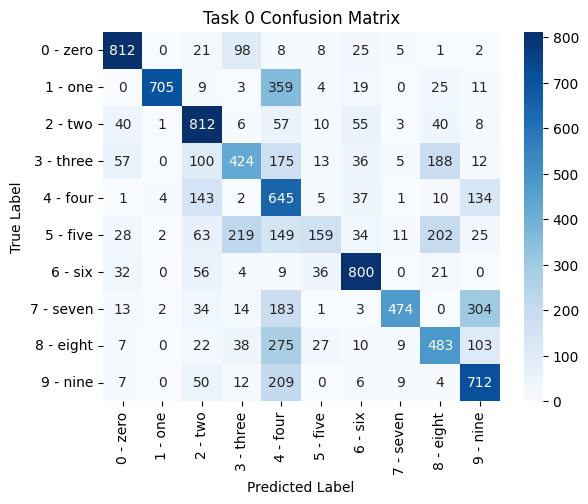

In [13]:
true_label = []
pred_label = []
with torch.no_grad():
    for data in task_1_loader:
        img, label = data
        img, label = img.to(device), label.to(device)
        output = model(img).argmax(1)
        true_label.extend(label.cpu().numpy())
        pred_label.extend(output.cpu().numpy())

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
print('\033[33m' + 'Accuracy' + '\033[0m', accuracy_score(true_label, pred_label))
print('\033[33m' + 'Classification Report' + '\033[0m',
      classification_report(true_label, pred_label, target_names=test_task_1.classes),
      sep='\n')
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_label, pred_label)
plt.cla(); plt.clf()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_task_1.classes, yticklabels=test_task_1.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Task 0 Confusion Matrix")
plt.show()

 - Task 1

Accuracy 0.8099
Classification Report
              precision    recall  f1-score   support

    0 - zero       0.82      0.88      0.85       980
     1 - one       0.92      0.97      0.94      1135
     2 - two       0.71      0.61      0.66      1032
   3 - three       0.78      0.82      0.80      1010
    4 - four       0.81      0.83      0.82       982
    5 - five       0.71      0.68      0.70       892
     6 - six       0.85      0.86      0.85       958
   7 - seven       0.89      0.86      0.88      1028
   8 - eight       0.75      0.71      0.73       974
    9 - nine       0.81      0.85      0.83      1009

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



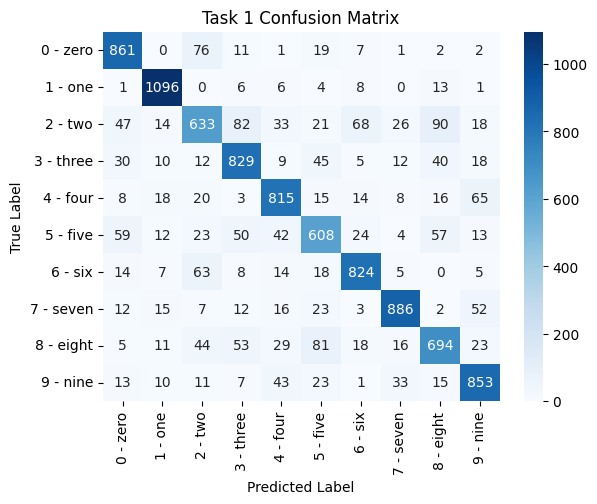

In [14]:
true_label = []
pred_label = []
with torch.no_grad():
    for data in task_2_loader:
        img, label = data
        img, label = img.to(device), label.to(device)
        output = model(img).argmax(1)
        true_label.extend(label.cpu().numpy())
        pred_label.extend(output.cpu().numpy())

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
print('\033[33m' + 'Accuracy' + '\033[0m', accuracy_score(true_label, pred_label))
print('\033[33m' + 'Classification Report' + '\033[0m',
      classification_report(true_label, pred_label, target_names=test_task_2.classes),
      sep='\n')
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_label, pred_label)
plt.cla(); plt.clf()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_task_2.classes, yticklabels=test_task_2.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Task 1 Confusion Matrix")
plt.show()

net.1.weight
torch.Size([10, 784])
Max fisher is 0.01949 and it's parameter diff is 0.00067
Min Parameter diff is 0.81032 and it's fisher is 0.00001
fisher > parameter diff: 97
fisher <= parameter diff: 687


<Figure size 640x480 with 0 Axes>

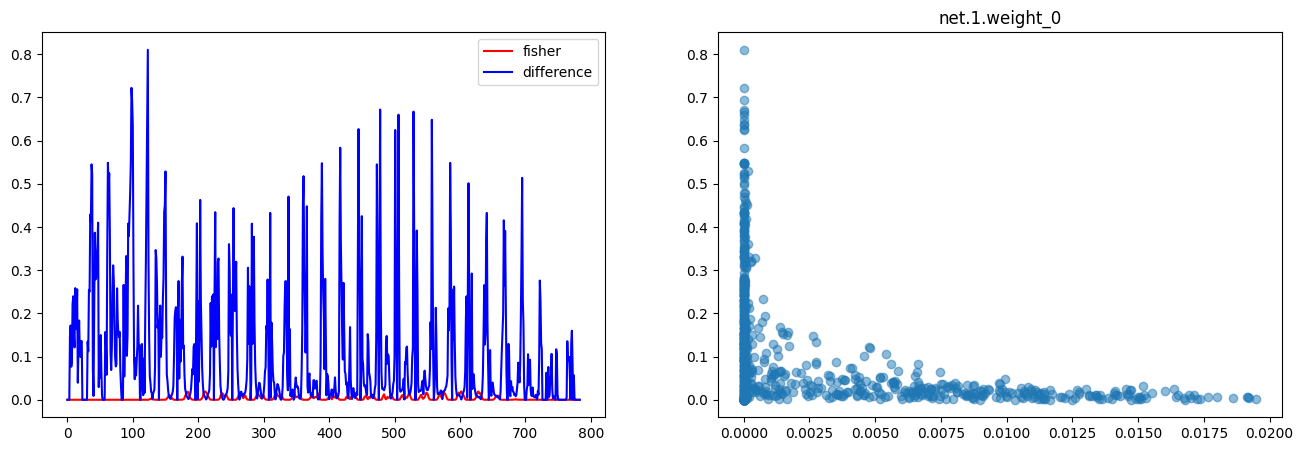

Max fisher is 0.01901 and it's parameter diff is 0.00189
Min Parameter diff is 0.85660 and it's fisher is 0.00000
fisher > parameter diff: 34
fisher <= parameter diff: 750


<Figure size 640x480 with 0 Axes>

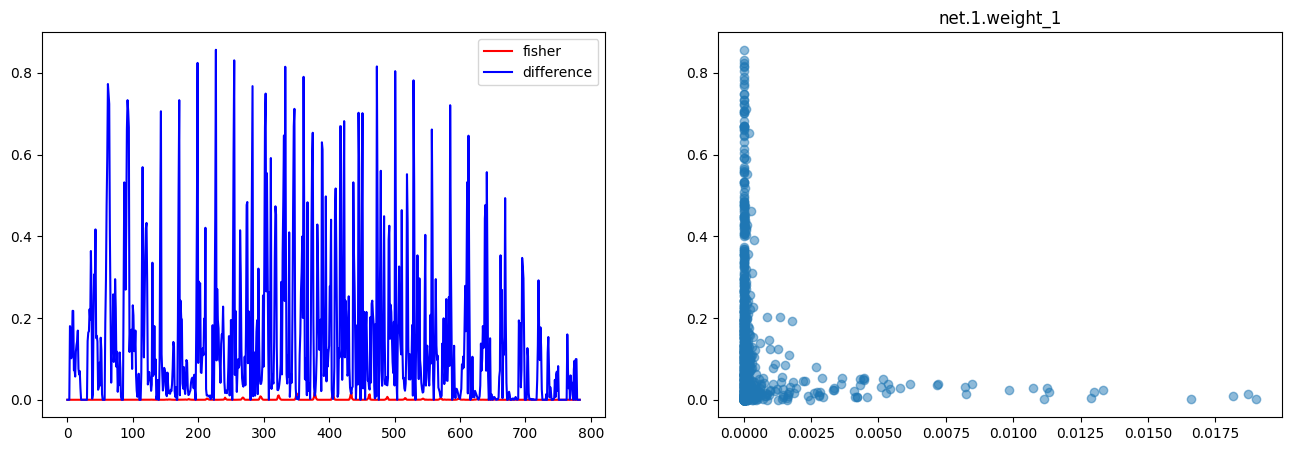

Max fisher is 0.04949 and it's parameter diff is 0.00094
Min Parameter diff is 0.97310 and it's fisher is 0.00000
fisher > parameter diff: 135
fisher <= parameter diff: 649


<Figure size 640x480 with 0 Axes>

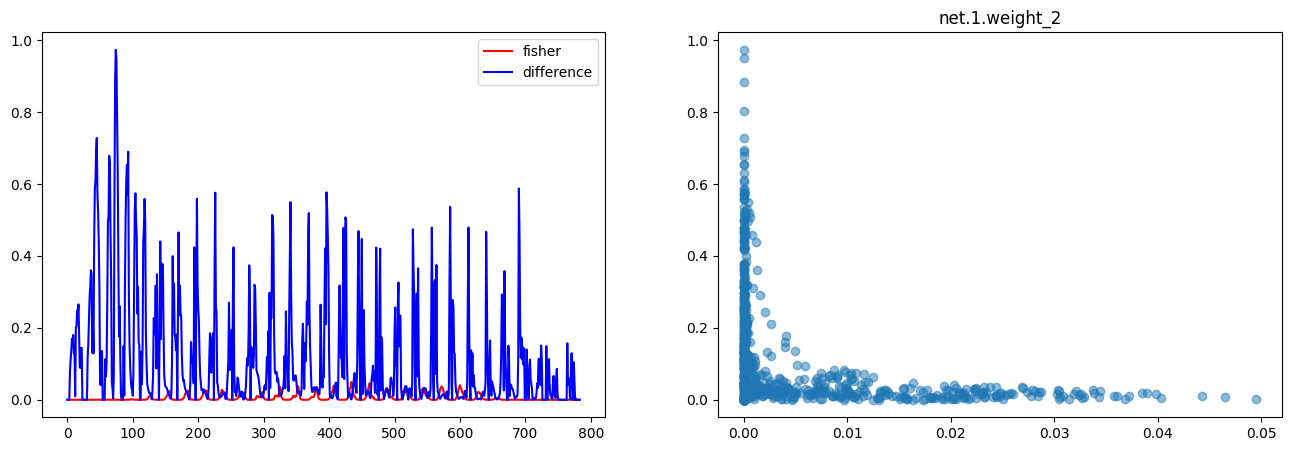

Max fisher is 0.00625 and it's parameter diff is 0.00289
Min Parameter diff is 0.70864 and it's fisher is 0.00000
fisher > parameter diff: 32
fisher <= parameter diff: 752


<Figure size 640x480 with 0 Axes>

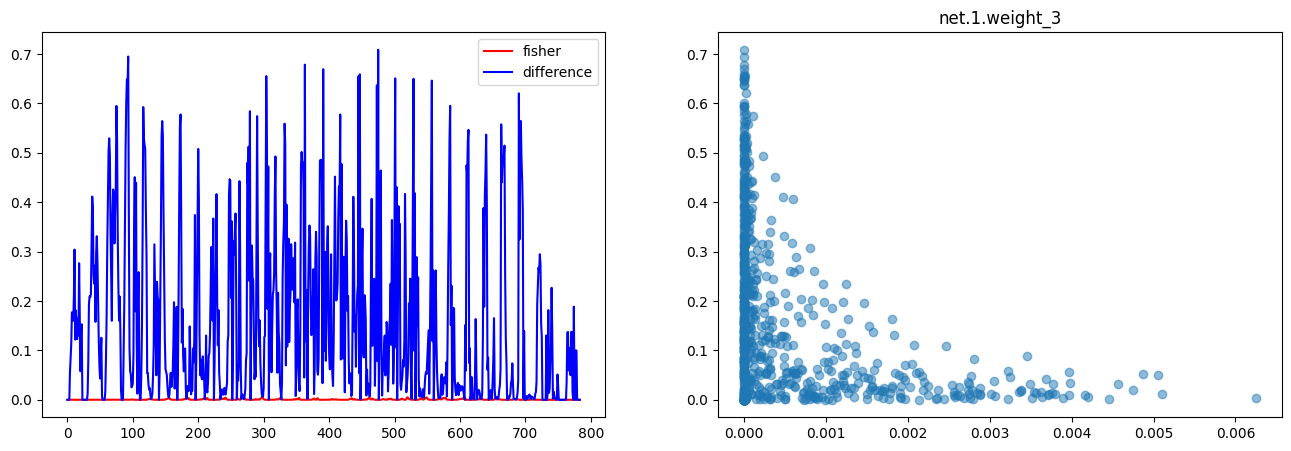

Max fisher is 0.00751 and it's parameter diff is 0.05732
Min Parameter diff is 0.90113 and it's fisher is 0.00015
fisher > parameter diff: 36
fisher <= parameter diff: 748


<Figure size 640x480 with 0 Axes>

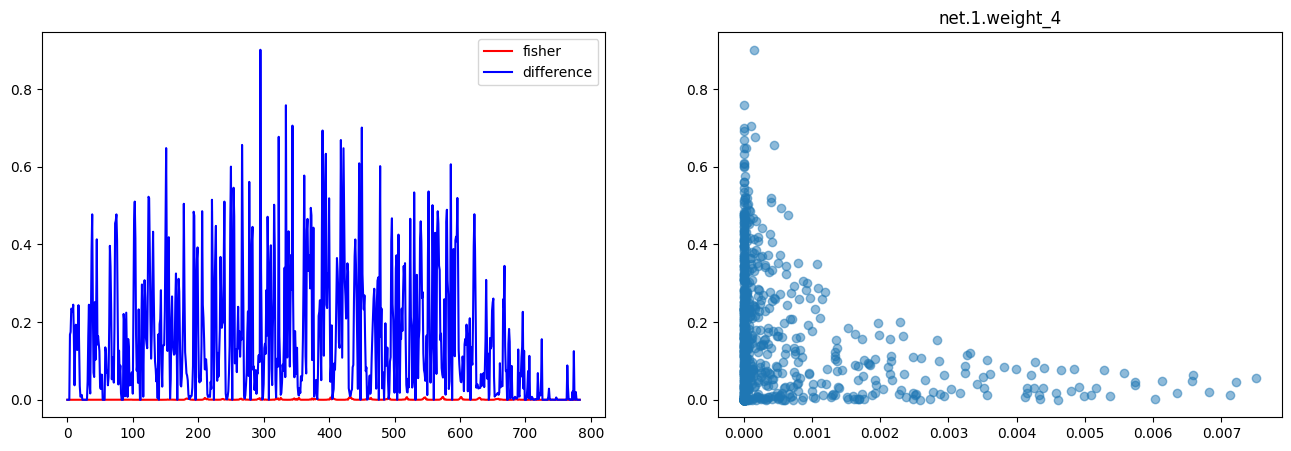

Max fisher is 0.01360 and it's parameter diff is 0.05842
Min Parameter diff is 1.03805 and it's fisher is 0.00000
fisher > parameter diff: 42
fisher <= parameter diff: 742


<Figure size 640x480 with 0 Axes>

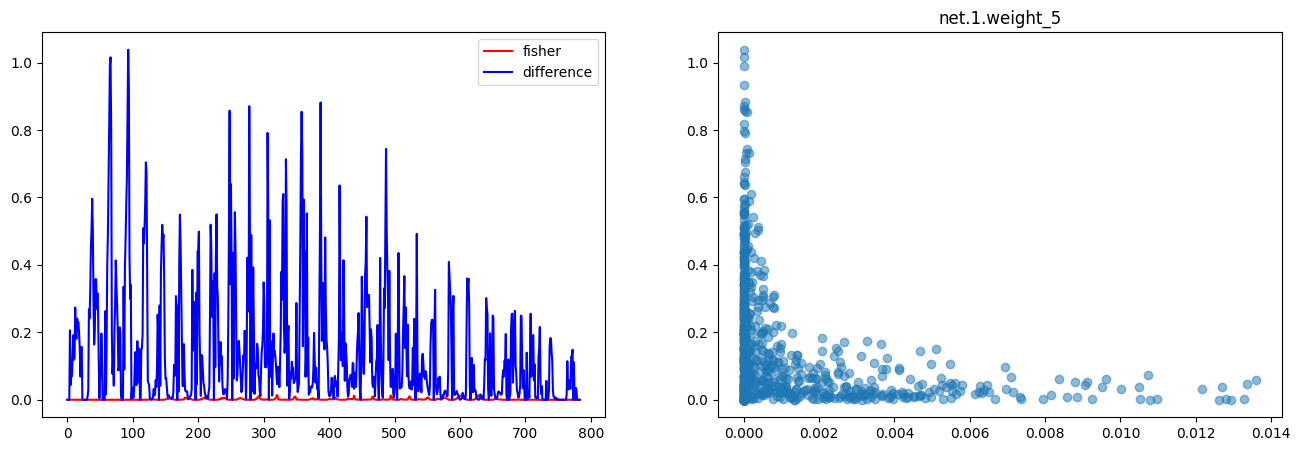

Max fisher is 0.02053 and it's parameter diff is 0.00072
Min Parameter diff is 0.81074 and it's fisher is 0.00000
fisher > parameter diff: 67
fisher <= parameter diff: 717


<Figure size 640x480 with 0 Axes>

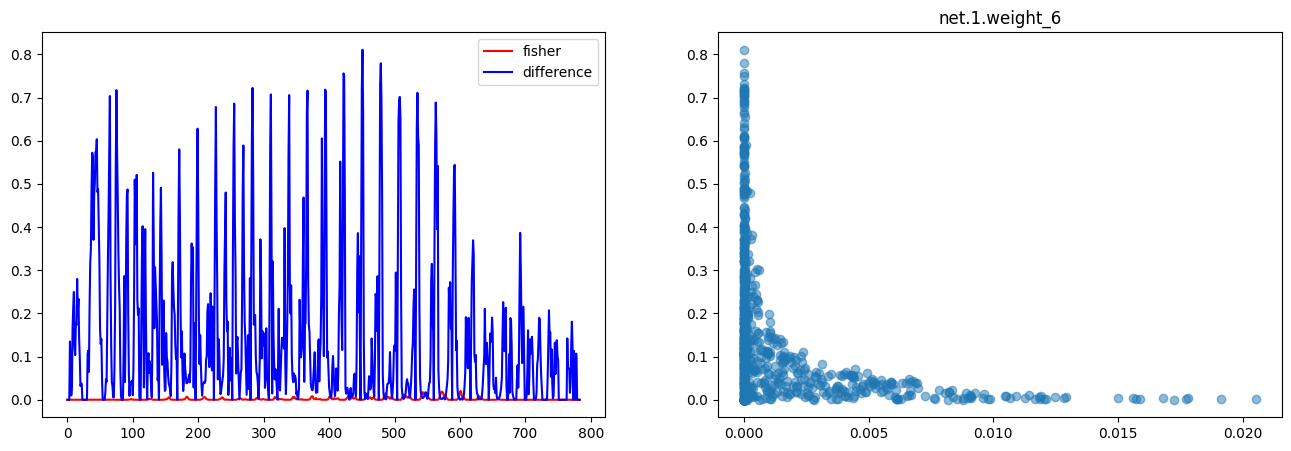

Max fisher is 0.00804 and it's parameter diff is 0.00509
Min Parameter diff is 0.78900 and it's fisher is 0.00000
fisher > parameter diff: 30
fisher <= parameter diff: 754


<Figure size 640x480 with 0 Axes>

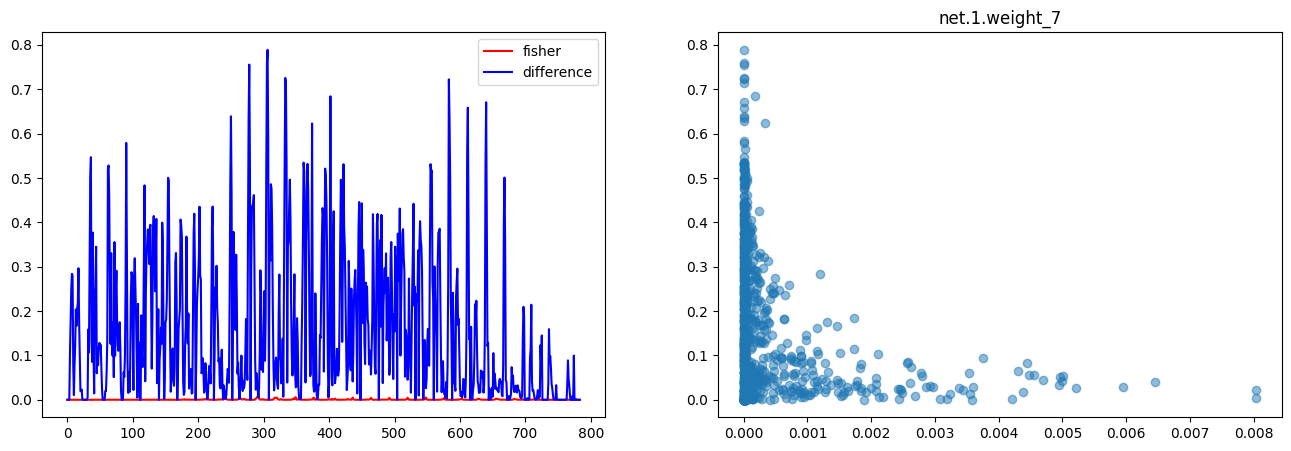

Max fisher is 0.03061 and it's parameter diff is 0.01110
Min Parameter diff is 0.90087 and it's fisher is 0.00003
fisher > parameter diff: 172
fisher <= parameter diff: 612


<Figure size 640x480 with 0 Axes>

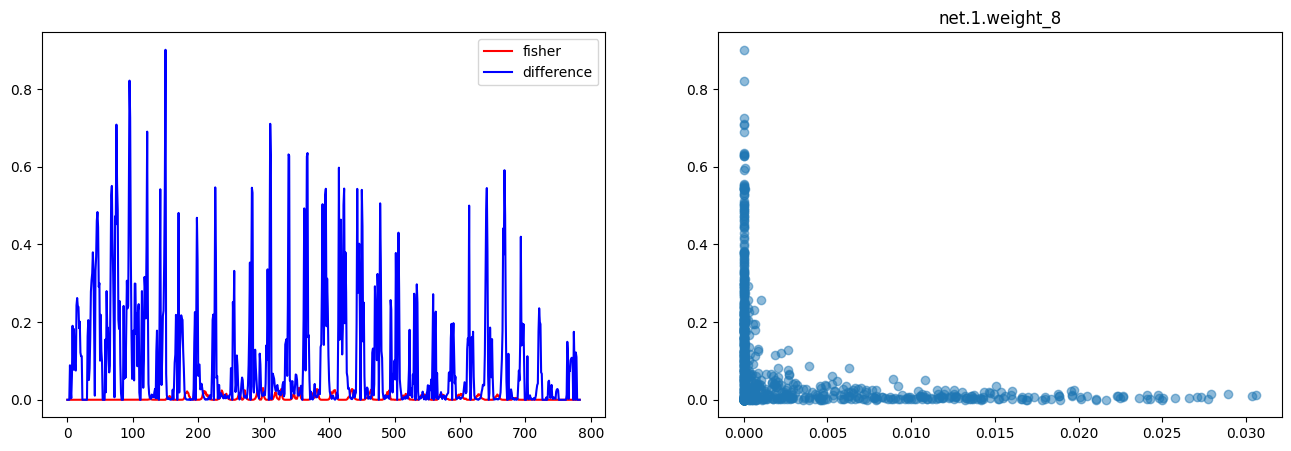

Max fisher is 0.01262 and it's parameter diff is 0.01762
Min Parameter diff is 0.84564 and it's fisher is 0.00000
fisher > parameter diff: 48
fisher <= parameter diff: 736


<Figure size 640x480 with 0 Axes>

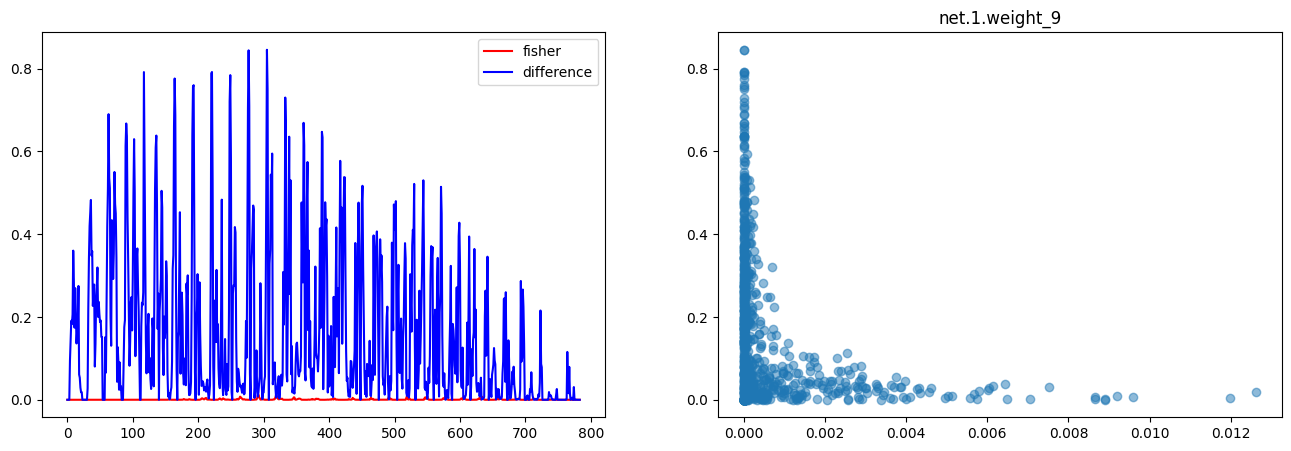


net.1.bias
torch.Size([10])
Max fisher is 0.08481 and it's parameter diff is 0.00033
Min Parameter diff is 0.29989 and it's fisher is 0.00113
fisher > parameter diff: 5
fisher <= parameter diff: 5


<Figure size 640x480 with 0 Axes>

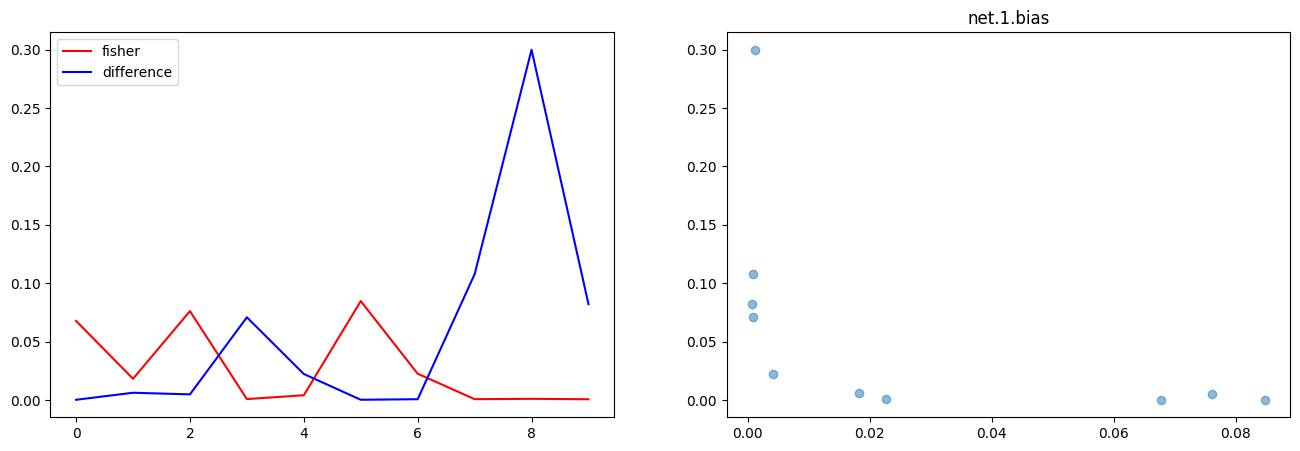

In [15]:
def plot(fisher_matrix, optim_para, param, name):
  plt.cla(); plt.clf()
  #print(fisher_matrix.shape, optim_para.shape, param.shape)
  fisher = fisher_matrix.cpu().detach()
  optim = optim_para.cpu().detach()
  param = param.cpu().detach()

  fisher_max = np.argmax(fisher)
  param_diff_max = np.argmax((optim - param).abs())
  print(f'Max fisher is {fisher[fisher_max]:.5f} and it\'s parameter diff is {(optim - param).abs()[fisher_max]:.5f}')
  print(f'Min Parameter diff is {(optim - param).abs()[param_diff_max]:.5f} and it\'s fisher is {fisher[param_diff_max]:.5f}')
  # compare
  print('fisher > parameter diff: {}'.format((fisher > (optim - param).abs()).sum()))
  print('fisher <= parameter diff: {}'.format((fisher <= (optim - param).abs()).sum()))

  # plot
  fig, ax = plt.subplots(1, 2, figsize=(16, 5)) # row, col
  ax[0].plot(fisher.reshape(-1), 'r', label='fisher')
  ax[0].plot((optim - param).abs().reshape(-1), 'b', label='difference')
  ax[0].legend()

  ax[1].scatter(fisher, (optim - param).abs().reshape(-1), alpha=0.5)
  plt.title(name)
  plt.show()

# test
idx = 0
for name, param in model.named_parameters():

  # Name
  print(name)
  print(param.detach().shape)

  if len(param.detach().shape) != 1:
    for i in range(param.detach().shape[0]):
      plot(fisher_matrix[0][name][i], optim_para[0][name][i], param[i], f'{name}_{i}')
  else:
    plot(fisher_matrix[0][name], optim_para[0][name], param, name)
  # END
  idx += 1
  print()

In [16]:
import datetime
import pytz

now = datetime.datetime.now(pytz.timezone('Asia/Taipei')).strftime("%Y-%m-%d_%H_%M_%S")
print(now)

2025-03-30_22_19_39
